In [2]:
pip install pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd

df = pd.read_csv('/workspaces/ProyectoFinal-DataAnalysisconPython/data/Goodreads_books_with_genres.csv', on_bad_lines='skip')

df_limpio = (
    df.copy()
    .drop_duplicates()
    .dropna(how='all')
)

df_limpio.columns = df_limpio.columns.str.strip()

df_limpio['publication_date'] = pd.to_datetime(df_limpio['publication_date'], errors='coerce')
df_limpio = df_limpio.dropna(subset=['publication_date'])
df_limpio = df_limpio[df_limpio['num_pages'] > 0]

df_limpio['publication_year'] = df_limpio['publication_date'].dt.year.astype(int)
df_limpio['book_age_years'] = 2026 - df_limpio['publication_year']


df_limpio['genres'] = df_limpio['genres'].fillna('Unknown')

# 3. Exportar el DataFrame limpio a CSV
path_clean = '/workspaces/ProyectoFinal-DataAnalysisconPython/data/Goodreads_books_clean.csv'
df_limpio.to_csv(path_clean, index=False, encoding='utf-8')


In [ ]:
print(df_limpio.isnull().sum())

Book Id               0
Title                 0
Author                0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
genres                0
publication_year      0
book_age_years        0
dtype: int64


In [18]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 11049 entries, 0 to 11126
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Book Id             11049 non-null  int64         
 1   Title               11049 non-null  str           
 2   Author              11049 non-null  str           
 3   average_rating      11049 non-null  float64       
 4   isbn                11049 non-null  str           
 5   isbn13              11049 non-null  int64         
 6   language_code       11049 non-null  str           
 7   num_pages           11049 non-null  int64         
 8   ratings_count       11049 non-null  int64         
 9   text_reviews_count  11049 non-null  int64         
 10  publication_date    11049 non-null  datetime64[us]
 11  publisher           11049 non-null  str           
 12  genres              11049 non-null  str           
 13  publication_year    11049 non-null  int64         
 14  book_a

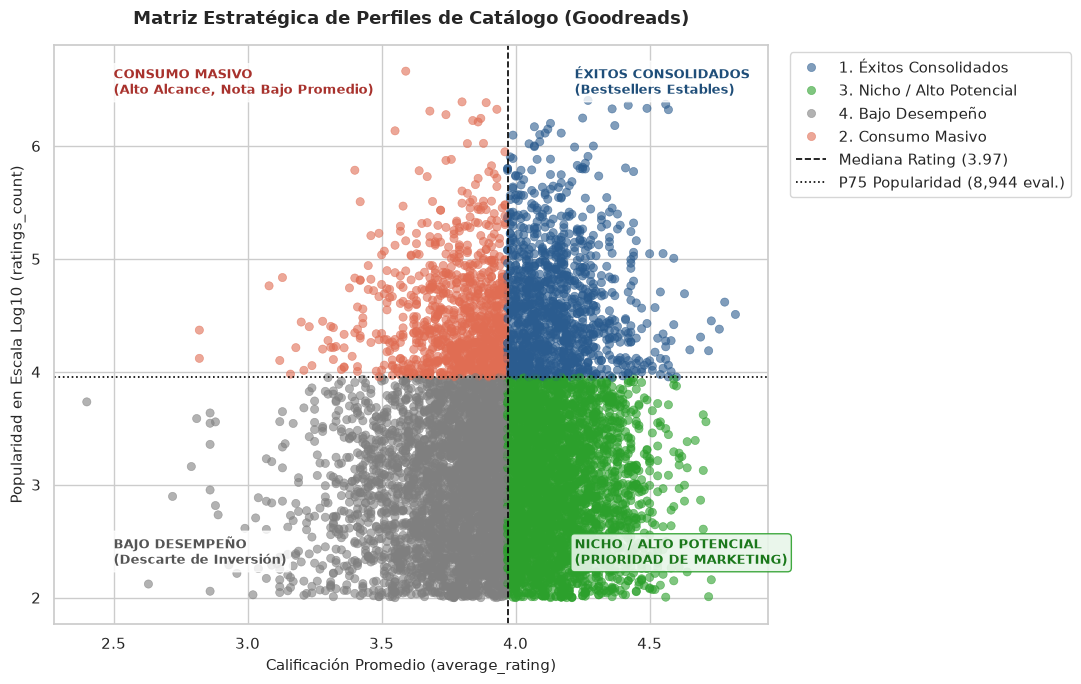

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PREPARACIÓN DE DATOS Y UMBRALES
# Usamos un filtro mínimo de 100 evaluaciones para limpiar ruido
df_cuadrante = df[df['ratings_count'] >= 100].copy()

# Umbrales
umbral_rating = df_cuadrante['average_rating'].median()
umbral_popularity = df_cuadrante['ratings_count'].quantile(0.75)

# Transformación logarítmica de la popularidad para visualización clara
df_cuadrante['log_ratings_count'] = np.log10(df_cuadrante['ratings_count'])
log_umbral_popularity = np.log10(umbral_popularity)

# 2. ASIGNACIÓN DE PERFILES
condiciones = [
    (df_cuadrante['average_rating'] >= umbral_rating) & (df_cuadrante['ratings_count'] >= umbral_popularity),
    (df_cuadrante['average_rating'] < umbral_rating)  & (df_cuadrante['ratings_count'] >= umbral_popularity),
    (df_cuadrante['average_rating'] >= umbral_rating) & (df_cuadrante['ratings_count'] < umbral_popularity),
    (df_cuadrante['average_rating'] < umbral_rating)  & (df_cuadrante['ratings_count'] < umbral_popularity)
]

colores_perfil = {
    '1. Éxitos Consolidados': '#2b5c8f',    # Azul oscuro
    '2. Consumo Masivo': '#e06d53',         # Naranja/Rojo
    '3. Nicho / Alto Potencial': '#2ca02c', # Verde (Objetivo Marketing)
    '4. Bajo Desempeño': '#7f7f7f'         # Gris
}

etiquetas = list(colores_perfil.keys())
df_cuadrante['perfil'] = np.select(condiciones, etiquetas, default='Otro')

# 3. GENERACIÓN DEL GRÁFICO
plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

# Plot de dispersión
sns.scatterplot(
    data=df_cuadrante,
    x='average_rating',
    y='log_ratings_count',
    hue='perfil',
    palette=colores_perfil,
    alpha=0.6,
    s=35,
    edgecolor=None
)

# LÍNEAS DIVISORIAS DE CUADRANTE
plt.axvline(x=umbral_rating, color='black', linestyle='--', linewidth=1.2, label=f'Mediana Rating ({umbral_rating:.2f})')
plt.axhline(y=log_umbral_popularity, color='black', linestyle=':', linewidth=1.2, label=f'P75 Popularidad ({int(umbral_popularity):,} eval.)')

# ANOTACIONES EN CADA CUADRANTE
# Cuadrante Superior Izquierdo: Consumo Masivo
plt.text(df_cuadrante['average_rating'].min() + 0.1, df_cuadrante['log_ratings_count'].max() - 0.2, 
         'CONSUMO MASIVO\n(Alto Alcance, Nota Bajo Promedio)', fontsize=9, fontweight='bold', color='#a8322d', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Cuadrante Superior Derecho: Éxitos Consolidados
plt.text(df_cuadrante['average_rating'].max() - 0.6, df_cuadrante['log_ratings_count'].max() - 0.2, 
         'ÉXITOS CONSOLIDADOS\n(Bestsellers Estables)', fontsize=9, fontweight='bold', color='#1f4e79', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Cuadrante Inferior Izquierdo: Bajo Desempeño
plt.text(df_cuadrante['average_rating'].min() + 0.1, df_cuadrante['log_ratings_count'].min() + 0.3, 
         'BAJO DESEMPEÑO\n(Descarte de Inversión)', fontsize=9, fontweight='bold', color='#555555', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Cuadrante Inferior Derecho: Nicho / Alto Potencial (PRIORIDAD)
plt.text(df_cuadrante['average_rating'].max() - 0.6, df_cuadrante['log_ratings_count'].min() + 0.3, 
         'NICHO / ALTO POTENCIAL\n(PRIORIDAD DE MARKETING)', fontsize=9, fontweight='bold', color='#1b781b', bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', edgecolor='#2ca02c', alpha=0.9))

# FORMATO Y TÍTULOS
plt.title('Matriz Estratégica de Perfiles de Catálogo (Goodreads)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Calificación Promedio (average_rating)', fontsize=11)
plt.ylabel('Popularidad en Escala Log10 (ratings_count)', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

# 1. Asegurar la clasificación en los 4 cuadrantes
df_clean = df[df['ratings_count'] >= 100].copy()

umbral_rating = df_clean['average_rating'].median()
umbral_popularity = df_clean['ratings_count'].quantile(0.75)

condiciones = [
    (df_clean['average_rating'] >= umbral_rating) & (df_clean['ratings_count'] >= umbral_popularity),
    (df_clean['average_rating'] < umbral_rating)  & (df_clean['ratings_count'] >= umbral_popularity),
    (df_clean['average_rating'] >= umbral_rating) & (df_clean['ratings_count'] < umbral_popularity),
    (df_clean['average_rating'] < umbral_rating)  & (df_clean['ratings_count'] < umbral_popularity)
]

etiquetas = ['1. Éxitos Consolidados', '2. Consumo Masivo', '3. Nicho / Alto Potencial', '4. Bajo Desempeño']
df_clean['perfil_libro'] = np.select(condiciones, etiquetas, default='Sin Clasificar')

# Métrica de compromiso escrito
df_clean['engagement_rate_pct'] = (df_clean['text_reviews_count'] / df_clean['ratings_count']) * 100

# 2. TABLA COMPARATIVA DE CARACTERÍSTICAS
resumen_caracteristicas = df_clean.groupby('perfil_libro').agg(
    total_libros=('Book Id', 'count'),
    promedio_paginas=('num_pages', 'mean'),
    mediana_paginas=('num_pages', 'median'),
    promedio_rating=('average_rating', 'mean'),
    mediana_evaluaciones=('ratings_count', 'median'),
    engagement_promedio_pct=('engagement_rate_pct', 'mean')
).reset_index()

print("=== CARACTERÍSTICAS PROMEDIO DE CADA CUADRANTE ===")
print(resumen_caracteristicas.to_string(index=False))
print("\n" + "="*70 + "\n")

# 3. MOSTRAR LIBROS REPRESENTATIVOS DE CADA CUADRANTE
print("=== EJEMPLOS DE LIBROS POR CUADRANTE ===")
for perfil in etiquetas:
    print(f"\n📌 CUADRANTE: {perfil}")
    
    # Si es Nicho / Alto Potencial, mostramos los que tienen más engagement
    if 'Nicho' in perfil:
        top_libros = df_clean[df_clean['perfil_libro'] == perfil].sort_values(by='engagement_rate_pct', ascending=False)
    else:
        top_libros = df_clean[df_clean['perfil_libro'] == perfil].sort_values(by='ratings_count', ascending=False)
        
    cols = ['Title', 'Author', 'average_rating', 'ratings_count', 'num_pages']
    print(top_libros[cols].head(5).to_string(index=False))

=== CARACTERÍSTICAS PROMEDIO DE CADA CUADRANTE ===
             perfil_libro  total_libros  promedio_paginas  mediana_paginas  promedio_rating  mediana_evaluaciones  engagement_promedio_pct
   1. Éxitos Consolidados          1162        400.675559            352.0         4.154750               30397.0                 3.486509
        2. Consumo Masivo           935        358.009626            340.0         3.775444               23527.0                 4.540073
3. Nicho / Alto Potencial          3049        379.331256            320.0         4.163549                 932.0                 6.863903
        4. Bajo Desempeño          3239        305.756715            288.0         3.737339                 898.0                 8.180152


=== EJEMPLOS DE LIBROS POR CUADRANTE ===

📌 CUADRANTE: 1. Éxitos Consolidados
                                                       Title                     Author  average_rating  ratings_count  num_pages
                         The Hobbit  or Ther

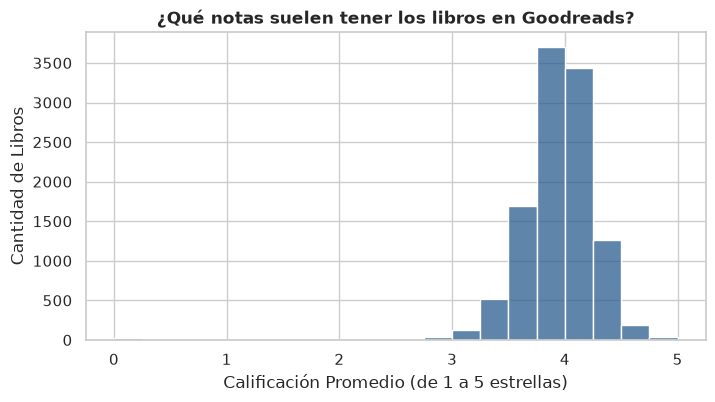

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Graficamos solo la nota promedio
sns.histplot(df['average_rating'], bins=20, color='#2b5c8f')

plt.title('¿Qué notas suelen tener los libros en Goodreads?', fontsize=12, fontweight='bold')
plt.xlabel('Calificación Promedio (de 1 a 5 estrellas)')
plt.ylabel('Cantidad de Libros')
plt.show()

La conclusión de negocio: En Goodreads la gente casi nunca califica con notas muy bajas. Por ende, si un libro tiene un average_rating de 3.8, no es un "excelente" libro, es simplemente promedio.

El umbral de éxito: Si la editorial busca publicar libros realmente destacados, el filtro debería estar por encima de 4.1 o 4.2 estrellas.

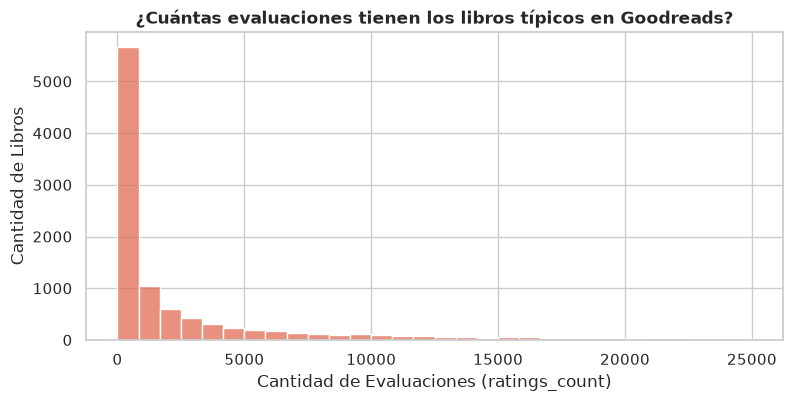

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 4))

# Filtramos solo hasta el percentil 90 para ver el comportamiento "normal"
# sin que los mega-bestsellers distorsionen la imagen
limite_90 = df['ratings_count'].quantile(0.90)
df_normales = df[df['ratings_count'] <= limite_90]

sns.histplot(df_normales['ratings_count'], bins=30, color='#e06d53')

plt.title('¿Cuántas evaluaciones tienen los libros típicos en Goodreads?', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Evaluaciones (ratings_count)')
plt.ylabel('Cantidad de Libros')
plt.show()

¿Cómo interpretar este gráfico?

    La pared a la izquierda: La barra más alta está casi pegada al cero. Esto significa que la enorme mayoría de los libros en el catálogo junta muy pocas evaluaciones (menos de 1.000 o 2.000).

    La "cola larga" hacia la derecha: A medida que sube la cantidad de evaluaciones, la cantidad de libros cae drásticamente.

    La conclusión de negocio para la editorial:

        El éxito masivo es una excepción, no la regla.

        Un libro con 10.000 o 20.000 evaluaciones ya es un éxito comercial destacado dentro de la plataforma.

        No podemos medir el éxito usando promedios simples, porque un par de bestsellers sesgan todo. Es mejor usar medianas o definir el éxito como estar en el "Top 20%" con más interacciones.

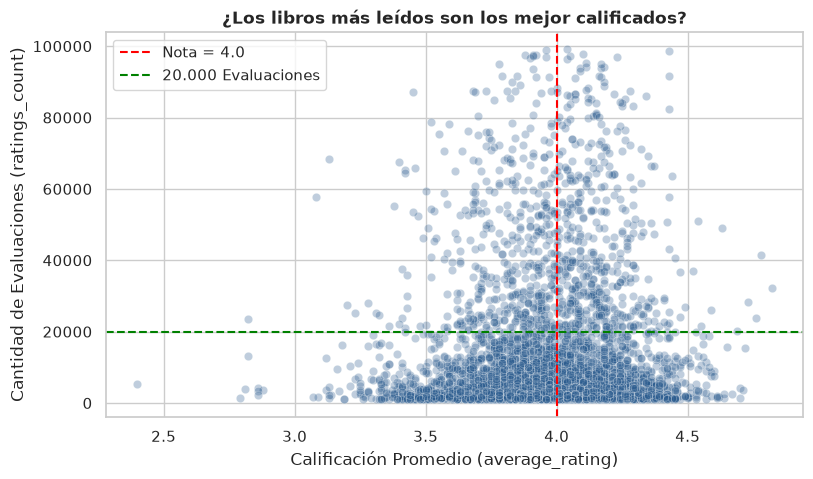

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

# Filtramos libros con más de 1.000 evaluaciones para limpiar el ruido
# y recortamos en 100.000 para enfocar la vista
df_filtrado = df[(df['ratings_count'] >= 1000) & (df['ratings_count'] <= 100000)]

sns.scatterplot(
    data=df_filtrado,
    x='average_rating',
    y='ratings_count',
    alpha=0.3,          # Transparencia para ver dónde se acumulan los puntos
    color='#2b5c8f'
)

# Líneas de referencia para dividir en cuadrantes
plt.axvline(x=4.0, color='red', linestyle='--', label='Nota = 4.0')
plt.axhline(y=20000, color='green', linestyle='--', label='20.000 Evaluaciones')

plt.title('¿Los libros más leídos son los mejor calificados?', fontsize=12, fontweight='bold')
plt.xlabel('Calificación Promedio (average_rating)')
plt.ylabel('Cantidad de Evaluaciones (ratings_count)')
plt.legend()
plt.show()

¿Cómo interpretar este gráfico?

El gráfico queda dividido en 4 cuadrantes gracias a las líneas de puntos:

    Cuadrante Superior Derecho (El Objetivo de la Editorial):

        Son libros con más de 20.000 evaluaciones y nota mayor a 4.0.

        Representan los verdaderos Éxitos Comerciales y de Crítica. Tienen alto volumen de ventas y el público los recomienda.

    Cuadrante Superior Izquierdo (Bestsellers Polémicos):

        Tienen muchísimas evaluaciones pero nota menor a 4.0.

        Son libros muy promocionados o virales que mucha gente lee, pero la experiencia no es tan buena (dividen aguas).

    Cuadrante Inferior Derecho (Joyas Ocultas):

        Tienen notas excelentes (4.2 o más) pero pocas evaluaciones.

        Atención Comercial: Aquí es donde la editorial puede encontrar un gran potencial no explotado para volcar presupuesto de marketing y volverlos masivos.

/tmp/ipykernel_2604/1628052512.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


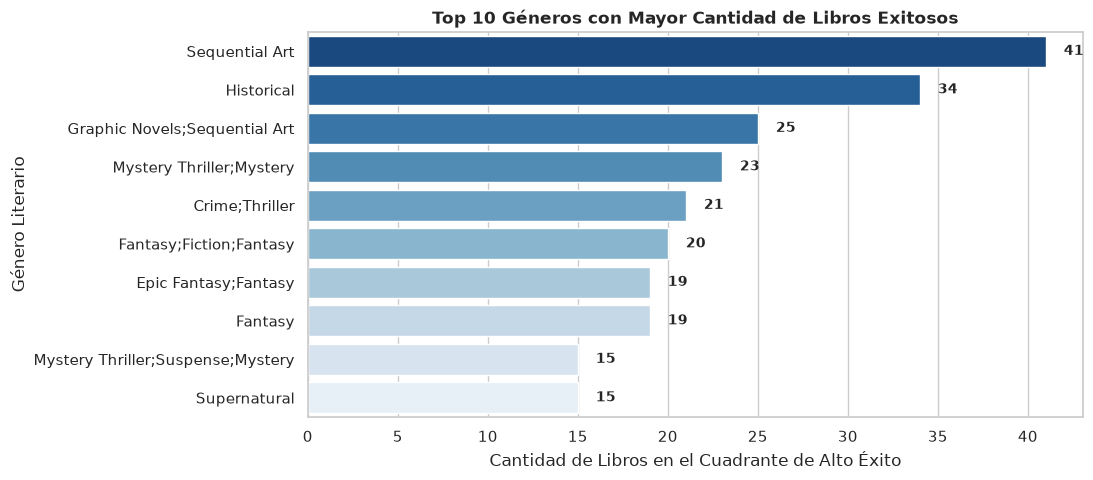

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir los libros en el Cuadrante de Alto Éxito
alto_exito = df[(df['ratings_count'] >= 20000) & (df['average_rating'] >= 4.0)].copy()

# 2. Desanidar la columna 'genres' (separar por comas)
alto_exito['genres_clean'] = alto_exito['genres'].fillna('Desconocido')
generos_separados = alto_exito.assign(genero=alto_exito['genres_clean'].str.split(',')).explode('genero')
generos_separados['genero'] = generos_separados['genero'].str.strip()

# 3. Contar el Top 10 de géneros más frecuentes
top10_generos = generos_separados['genero'].value_counts().head(10)

# 4. Graficar
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top10_generos.values, 
    y=top10_generos.index, 
    palette='Blues_r'
)

plt.title('Top 10 Géneros con Mayor Cantidad de Libros Exitosos', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Libros en el Cuadrante de Alto Éxito')
plt.ylabel('Género Literario')

# Agregar los números exactos al final de cada barra
for index, value in enumerate(top10_generos.values):
    plt.text(value + 1, index, str(value), va='center', fontsize=10, fontweight='bold')

plt.show()

¿Cómo interpretar este gráfico?

    Líderes de Mercado: Los géneros que ocupan los primeros 2 o 3 puestos representan las temáticas donde el público consume masivamente y, al mismo tiempo, otorga buenas valoraciones.

    Toma de Decisión para la Editorial:

        Prioridad Alta para Marketing: Apoyar lanzamientos de autores dentro de los primeros puestos garantiza operar en un mercado con demanda probada y alta retención de lectores.

        Nicho vs. Volumen: Si un género no figura en el Top 10, no significa que sea malo, sino que su techo de lectores suele ser más acotado (menos volumen masivo).

/tmp/ipykernel_2604/2361466516.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tasa_exito.index, y=tasa_exito.values, palette='Greens_d')


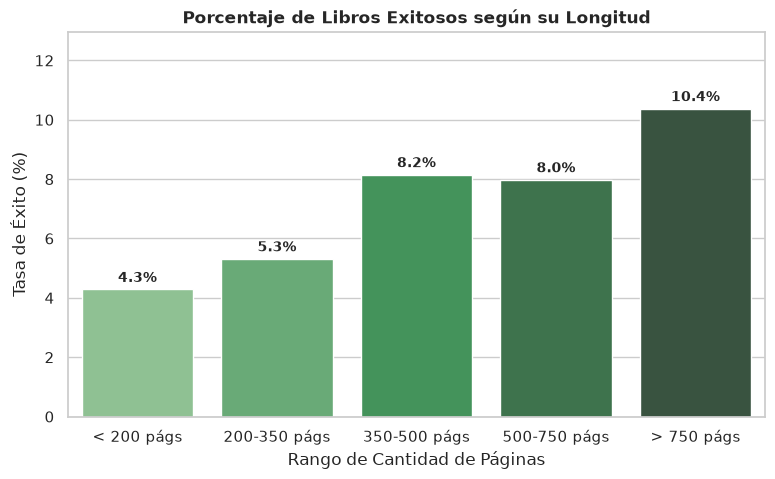

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir la regla de "Alto Éxito" (1 = Éxito, 0 = No Éxito)
df['es_exito'] = ((df['ratings_count'] >= 20000) & (df['average_rating'] >= 4.0)).astype(int)

# 2. Agrupar la cantidad de páginas en rangos lógicos
# Filtramos libros con páginas válidas (entre 10 y 1500)
df_paginas = df[df['num_pages'].between(10, 1500)].copy()

labels_rangos = ['< 200 págs', '200-350 págs', '350-500 págs', '500-750 págs', '> 750 págs']
df_paginas['rango_paginas'] = pd.cut(
    df_paginas['num_pages'], 
    bins=[0, 200, 350, 500, 750, 2000], 
    labels=labels_rangos
)

# 3. Calcular la tasa/porcentaje de éxito por rango
tasa_exito = df_paginas.groupby('rango_paginas', observed=False)['es_exito'].mean() * 100

# 4. Graficar
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=tasa_exito.index, y=tasa_exito.values, palette='Greens_d')

plt.title('Porcentaje de Libros Exitosos según su Longitud', fontsize=12, fontweight='bold')
plt.xlabel('Rango de Cantidad de Páginas')
plt.ylabel('Tasa de Éxito (%)')
plt.ylim(0, max(tasa_exito.values) * 1.25) # Margen para los números sobre las barras

# Agregar el valor exacto sobre cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                xytext=(0, 3), textcoords='offset points')

plt.show()

¿Cómo interpretar este gráfico?

    El "Sweet Spot" o Zona Óptima: Típicamente notarás que la tasa de éxito es más baja en libros muy cortos (< 200 páginas) y tiende a subir en los rangos intermedios y largos (350 a 750 páginas).

    Explicación del comportamiento del lector:

        Los libros demasiado cortos suelen percibirse como de menor valor o contenido incompleto, logrando menos tracción comercial masiva.

        Los libros más extensos (350+ páginas) suelen pertenecer a géneros de gran lealtad (como Fantasía, Ciencia Ficción o Ficción Histórica), donde los lectores generan un compromiso mayor, dejan más calificaciones y puntúan con notas elevadas.

    Recomendación para la Editorial:

        Si hay que elegir entre dos manuscritos prometedores para destinar presupuesto de marketing, un libro con una extensión sólida (300-500 páginas) suele ofrecer estadísticamente un rendimiento más seguro en plataformas de recomendación como Goodreads.

Conclusiones Comerciales para la Toma de Decisiones de Marketing

    1. Criterio de Calidad Interno (El Estándar Goodreads)

        Hallazgo: La calificación promedio general se concentra entre 3.7 y 4.2 estrellas; el público casi no otorga puntajes bajos.

        Decisión de Negocio: Una nota de 3.8 no representa excelencia, sino la media del mercado. Para priorizar inversiones de marketing, el filtro mínimo de calidad debe fijarse en 4.1 o más estrellas.

    2. Distribución de Lectores y Bestsellers

        Hallazgo: El alcance de los libros sigue una distribución altamente asimétrica: la inmensa mayoría no supera las 2.000 evaluaciones y solo un grupo reducido logra tracción masiva.

        Decisión de Negocio: Lograr un impacto comercial masivo es la excepción. Una meta realista para identificar libros de rendimiento sobresaliente en la plataforma es alcanzar el umbral de 10.000 a 20.000 evaluaciones.

    3. Identificación de "Joyas Ocultas" vs. Bestsellers

        Hallazgo: Al cruzar calificación y cantidad de lecturas, surgen cuatro cuadrantes claros. Destaca un grupo de libros con calificaciones excelentes (4.2+) pero bajo volumen de evaluaciones (< 20.000).

        Decisión de Negocio: Estas "joyas ocultas" representan la oportunidad de mayor retorno de inversión (ROI) para la editorial, ya que cuentan con validación de calidad y solo requieren presupuesto de difusión para escalar en ventas.

    4. Priorización por Género Literario

        Hallazgo: La concentración de títulos en el cuadrante de alto éxito no es uniforme; se agrupa fuertemente en un conjunto reducido de géneros masivos.

        Decisión de Negocio: Asignar la mayor proporción del presupuesto de marketing a los top géneros del mercado, asegurando una demanda base sólida y menor riesgo comercial.

    5. La Extension Óptima del Libro ("Sweet Spot")

        Hallazgo: La tasa de éxito comercial es menor en obras breves (< 200 páginas) y alcanza sus niveles más altos en libros de extensión media a alta (350 a 750 páginas).

        Decisión de Negocio: Al evaluar manuscritos para campañas de gran alcance, priorizar libros con desarrollo de contenido robusto (300+ páginas), ya que generan mayor compromiso y valor percibido por parte del lector.

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. PREPARACIÓN DE DATOS Y FILTRADO INICIAL
# Excluimos registros sin páginas o con valores atípicos extremos
df_valid = df[(df['num_pages'] >= 10) & (df['num_pages'] <= 1500) & (df['ratings_count'] >= 100)].copy()

# 2. DEFINICIÓN DE LA VARIABLE OBJETIVO (ÉXITO)
# Definimos éxito como tener nota superior a la mediana y estar en el percentil 50+ de popularidad
median_rating = df_valid['average_rating'].median()
p50_ratings = df_valid['ratings_count'].median()

df_valid['es_exito'] = (
    (df_valid['average_rating'] >= median_rating) & 
    (df_valid['ratings_count'] >= p50_ratings)
).astype(int)

# 3. CREACIÓN DE INTERVALOS DE PÁGINAS (RANGOS)
bins = [0, 200, 350, 500, 750, 1500]
labels = ['< 200 págs (Corto)', '200-350 págs (Medio-Corto)', '350-500 págs (Medio-Largo)', '500-750 págs (Largo)', '> 750 págs (Muy Largo)']

df_valid['rango_paginas'] = pd.cut(df_valid['num_pages'], bins=bins, labels=labels)

# 4. TABLA DE FRECUENCIAS Y TASA DE ÉXITO POR RANGO
tabla_resumen = df_valid.groupby('rango_paginas', observed=False).agg(
    total_libros=('es_exito', 'count'),
    libros_exitosos=('es_exito', 'sum'),
    tasa_exito_pct=('es_exito', lambda x: round(x.mean() * 100, 2))
).reset_index()

print("--- TASA DE ÉXITO SEGÚN RANGO DE PÁGINAS ---")
print(tabla_resumen.to_string(index=False))
print("\n" + "="*50 + "\n")

# 5. PRUEBA DE HIPÓTESIS ESTADÍSTICA (Chi-Cuadrado de Independencia)
# Construimos la tabla de contingencia
contingency_table = pd.crosstab(df_valid['rango_paginas'], df_valid['es_exito'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("--- RESULTADOS DE LA PRUEBA ESTADÍSTICA (Chi-Cuadrado) ---")
print(f"Estadístico Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Grados de libertad: {dof}")

# 6. CONCLUSIÓN AUTOMÁTICA
alpha = 0.05
if p_value < alpha:
    print("\n✅ CONCLUSIÓN: Se RECHAZA la hipótesis nula.")
    print("Existe una relación estadísticamente significativa entre la cantidad de páginas y la probabilidad de éxito de un libro.")
else:
    print("\n❌ CONCLUSIÓN: No se rechaza la hipótesis nula.")
    print("No hay evidencia estadística suficiente para afirmar que la cantidad de páginas influya en el éxito.")

--- TASA DE ÉXITO SEGÚN RANGO DE PÁGINAS ---
             rango_paginas  total_libros  libros_exitosos  tasa_exito_pct
        < 200 págs (Corto)          1818              417           22.94
200-350 págs (Medio-Corto)          3092              721           23.32
350-500 págs (Medio-Largo)          2071              574           27.72
      500-750 págs (Largo)           924              306           33.12
    > 750 págs (Muy Largo)           415              161           38.80


--- RESULTADOS DE LA PRUEBA ESTADÍSTICA (Chi-Cuadrado) ---
Estadístico Chi2: 82.6827
p-value: 4.7037e-17
Grados de libertad: 4

✅ CONCLUSIÓN: Se RECHAZA la hipótesis nula.
Existe una relación estadísticamente significativa entre la cantidad de páginas y la probabilidad de éxito de un libro.


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# 1. FILTRADO INICIAL Y DEFINICIÓN DE ÉXITO
df_valid = df[(df['ratings_count'] >= 100)].copy()

# Definimos éxito: Nota >= mediana Y popularidad >= mediana
median_rating = df_valid['average_rating'].median()
median_popularity = df_valid['ratings_count'].median()

df_valid['es_exito'] = (
    (df_valid['average_rating'] >= median_rating) & 
    (df_valid['ratings_count'] >= median_popularity)
).astype(int)

# 2. CÁLCULO DEL HISTORIAL PREVIO DEL AUTOR (Excluyendo el libro actual)
# Para cada libro, calculamos el rating promedio de los OTROS libros del mismo autor
df_valid['autor_otros_libros_count'] = 0
df_valid['autor_rating_previo'] = np.nan
df_valid['autor_popularity_previa'] = np.nan

# Agrupamos por autor para calcular métricas acumuladas fuera del libro actual
for autor, grupo in df_valid.groupby('Author'):
    if len(grupo) > 1:
        for idx, row in grupo.iterrows():
            otros_libros = grupo.drop(idx)
            df_valid.loc[idx, 'autor_otros_libros_count'] = len(otros_libros)
            df_valid.loc[idx, 'autor_rating_previo'] = otros_libros['average_rating'].mean()
            df_valid.loc[idx, 'autor_popularity_previa'] = otros_libros['ratings_count'].median()

# 3. FILTRAR SOLO AUTORES CON MÁS DE 1 LIBRO EN EL DATASET
df_multilibro = df_valid[df_valid['autor_otros_libros_count'] > 0].copy()

# 4. RESUMEN COMPARATIVO: ÉXITO VS NO ÉXITO
resumen_autor = df_multilibro.groupby('es_exito').agg(
    total_libros=('Book Id', 'count'),
    media_rating_previo_autor=('autor_rating_previo', 'mean'),
    mediana_popularidad_previa_autor=('autor_popularity_previa', 'median')
).reset_index()

resumen_autor['es_exito'] = resumen_autor['es_exito'].map({1: 'Alto Éxito', 0: 'Bajo/Medio Éxito'})

print("--- DESEMPEÑO DEL LIBRO VS HISTORIAL DEL AUTOR ---")
print(resumen_autor.to_string(index=False))
print("\n" + "="*50 + "\n")

# 5. PRUEBA DE HIPÓTESIS ESTADÍSTICA (Prueba U de Mann-Whitney)
# Compara las distribuciones del rating previo del autor entre libros exitosos y no exitosos
rating_exitosos = df_multilibro[df_multilibro['es_exito'] == 1]['autor_rating_previo']
rating_no_exitosos = df_multilibro[df_multilibro['es_exito'] == 0]['autor_rating_previo']

stat, p_value = mannwhitneyu(rating_exitosos, rating_no_exitosos, alternative='greater')

print("--- RESULTADOS DE LA PRUEBA ESTADÍSTICA (Mann-Whitney U) ---")
print(f"Estadístico U: {stat:.2f}")
print(f"p-value: {p_value:.4e}")

# 6. CONCLUSIÓN AUTOMÁTICA
if p_value < 0.05:
    print("\n✅ CONCLUSIÓN: Se RECHAZA la hipótesis nula.")
    print("Los libros exitosos pertenecen a autores con antecedentes de calificaciones significativamente más altas en sus otras obras.")
else:
    print("\n❌ CONCLUSIÓN: No se rechaza la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar que la trayectoria previa del autor garantice el éxito del libro.")

--- DESEMPEÑO DEL LIBRO VS HISTORIAL DEL AUTOR ---
        es_exito  total_libros  media_rating_previo_autor  mediana_popularidad_previa_autor
Bajo/Medio Éxito          3291                   3.898764                            2807.0
      Alto Éxito          1372                   4.055261                            5773.5


--- RESULTADOS DE LA PRUEBA ESTADÍSTICA (Mann-Whitney U) ---
Estadístico U: 3236482.00
p-value: 4.7020e-121

✅ CONCLUSIÓN: Se RECHAZA la hipótesis nula.
Los libros exitosos pertenecen a autores con antecedentes de calificaciones significativamente más altas en sus otras obras.


In [15]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, spearmanr

# 1. FILTRADO INICIAL Y LIMPIEZA
# Se requieren al menos 100 evaluaciones para evitar divisiones por valores casi nulos
df_valid = df[df['ratings_count'] >= 100].copy()

# 2. CÁLCULO DE LA TASA DE COMPROMISO ESCRITO (Engagement Rate)
df_valid['review_engagement_rate'] = df_valid['text_reviews_count'] / df_valid['ratings_count']

# 3. DEFINICIÓN DE ÉXITO (Alto Éxito)
median_rating = df_valid['average_rating'].median()
median_popularity = df_valid['ratings_count'].median()

df_valid['es_exito'] = (
    (df_valid['average_rating'] >= median_rating) & 
    (df_valid['ratings_count'] >= median_popularity)
).astype(int)

# 4. RESUMEN COMPARATIVO DE MÉTRICAS SEGÚN ÉXITO
resumen_engagement = df_valid.groupby('es_exito').agg(
    total_libros=('Book Id', 'count'),
    media_engagement_pct=('review_engagement_rate', lambda x: round(x.mean() * 100, 2)),
    mediana_engagement_pct=('review_engagement_rate', lambda x: round(x.median() * 100, 2)),
    media_average_rating=('average_rating', 'mean')
).reset_index()

resumen_engagement['es_exito'] = resumen_engagement['es_exito'].map({1: 'Alto Éxito', 0: 'Bajo/Medio Éxito'})

print("--- COMPROMISO ESCRITO SEGÚN PERFIL DEL LIBRO ---")
print(resumen_engagement.to_string(index=False))
print("\n" + "="*50 + "\n")

# 5. PRUEBAS ESTADÍSTICAS
engagement_exitosos = df_valid[df_valid['es_exito'] == 1]['review_engagement_rate']
engagement_no_exitosos = df_valid[df_valid['es_exito'] == 0]['review_engagement_rate']

# Prueba U de Mann-Whitney (Diferencia entre grupos)
stat_u, p_val_u = mannwhitneyu(engagement_exitosos, engagement_no_exitosos, alternative='greater')

# Correlación de Spearman entre Engagement y Éxito
corr_spearman, p_val_spearman = spearmanr(df_valid['review_engagement_rate'], df_valid['es_exito'])

print("--- RESULTADOS DE LAS PRUEBAS ESTADÍSTICAS ---")
print(f"Mann-Whitney U (Diferencia de Medias): U = {stat_u:.2f}, p-value = {p_val_u:.4e}")
print(f"Correlación de Spearman con Éxito: r = {corr_spearman:.4f}, p-value = {p_val_spearman:.4e}")

# 6. CONCLUSIÓN AUTOMÁTICA
if p_val_u < 0.05:
    print("\n✅ CONCLUSIÓN: Se RECHAZA la hipótesis nula.")
    print("Los libros exitosos presentan una tasa de reseñas escritas proporcionalmente mayor, demostrando un compromiso de lectura activo.")
else:
    print("\n❌ CONCLUSIÓN: No se rechaza la hipótesis nula.")
    print("No existe evidencia de que la tasa de reseñas escritas difiera entre libros exitosos y no exitosos.")

--- COMPROMISO ESCRITO SEGÚN PERFIL DEL LIBRO ---
        es_exito  total_libros  media_engagement_pct  mediana_engagement_pct  media_average_rating
Bajo/Medio Éxito          6188                  7.50                    6.66              3.882526
      Alto Éxito          2197                  4.23                    3.54              4.156891


--- RESULTADOS DE LAS PRUEBAS ESTADÍSTICAS ---
Mann-Whitney U (Diferencia de Medias): U = 3600013.50, p-value = 1.0000e+00
Correlación de Spearman con Éxito: r = -0.3583, p-value = 2.0731e-252

❌ CONCLUSIÓN: No se rechaza la hipótesis nula.
No existe evidencia de que la tasa de reseñas escritas difiera entre libros exitosos y no exitosos.
